In [ ]:
from google.colab import files
uploaded = files.upload()

Saving flower_data_set.zip to flower_data_set.zip


In [ ]:
from google.colab import files
import os

model_path = 'flower_model.keras'

if os.path.exists(model_path):
    files.download(model_path)
else:
    print(f'ไม่พบไฟล์ {model_path} กรุณารันเซลล์ที่สั่ง model.save() ก่อนครับ')

ไม่พบไฟล์ flower_model.keras กรุณารันเซลล์ที่สั่ง model.save() ก่อนครับ


In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content")

print(os.listdir("/content"))

['.config', 'flower_data_set', 'flower_data_set.zip', 'drive', 'sample_data']


In [ ]:
import os

base_path = "/content/flower_data_set"
print(os.listdir(base_path))

['roses', 'tulips', 'daisy', 'sunflowers', 'dandelion']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=16
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1376 files belonging to 5 classes.
Using 1101 files for training.
Found 1376 files belonging to 5 classes.
Using 275 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

In [ ]:
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32,(3,3),activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from google.colab import drive
import tensorflow as tf

# 1. เชื่อมต่อ Google Drive เพื่อเตรียมบันทึกไฟล์
drive.mount('/content/drive')

# 2. ตั้งค่า Callback เพื่อบันทึกเฉพาะน้ำหนักที่ดีที่สุด (Best Weights)
checkpoint_filepath = 'best_flower_weights.weights.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 3. เริ่มต้นการฝึกโมเดล
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[model_checkpoint_callback]
)

# 4. บันทึกโมเดลฉบับสมบูรณ์ลงใน Google Drive หลังจากเทรนเสร็จ
drive_save_path = '/content/drive/MyDrive/flower_model_final.keras'
model.save(drive_save_path)

print(f'\nการเทรนเสร็จสิ้น! บันทึกโมเดลไว้ใน Google Drive เรียบร้อยแล้วที่: {drive_save_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9693 - loss: 0.0815
Epoch 1: val_accuracy improved from None to 0.90182, saving model to best_flower_weights.weights.h5

Epoch 1: finished saving model to best_flower_weights.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9718 - loss: 0.0822 - val_accuracy: 0.9018 - val_loss: 0.5727
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9798 - loss: 0.0827
Epoch 2: val_accuracy did not improve from 0.90182
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9773 - loss: 0.0739 - val_accuracy: 0.8655 - val_loss: 0.5849
Epoch 3/20
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9550 - loss: 0.1183
Epoch 3: val_accuracy did not improve from 0.90182
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9600 - loss: 0.1083 - val_accuracy: 0.8691 - val_loss: 0.5645


Saving 148180650_19a4b410db.jpg to 148180650_19a4b410db.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


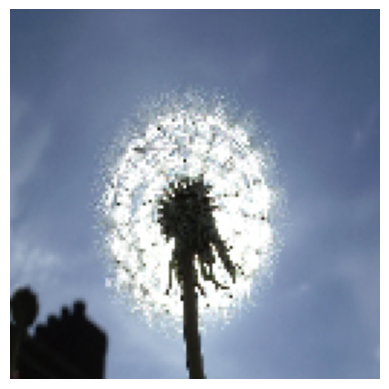

ผลการทำนาย: dandelion
ความมั่นใจ: 100.00%


In [ ]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. อัปโหลดรูปภาพที่ต้องการทำนาย
uploaded_file = files.upload()

for fn in uploaded_file.keys():
    # 2. โหลดและปรับขนาดรูปภาพให้ตรงกับที่โมเดลต้องการ (128x128)
    img_path = fn
    img = image.load_img(img_path, target_size=(128, 128))

    # 3. แปลงรูปภาพเป็น Array และเตรียมข้อมูลสำหรับ Predict
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # เพิ่มมิติ batch

    # 4. ทำนายผล
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # 5. แสดงผลลัพธ์
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    print(f'ผลการทำนาย: {class_names[np.argmax(predictions)]}')
    print(f'ความมั่นใจ: {100 * np.max(predictions):.2f}%')